<a href="https://colab.research.google.com/github/Brunoxue/hsi_examples/blob/main/sklearn_classification_indian_pines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://huggingface.co/datasets/danaroth/indian_pines

fatal: destination path 'indian_pines' already exists and is not an empty directory.


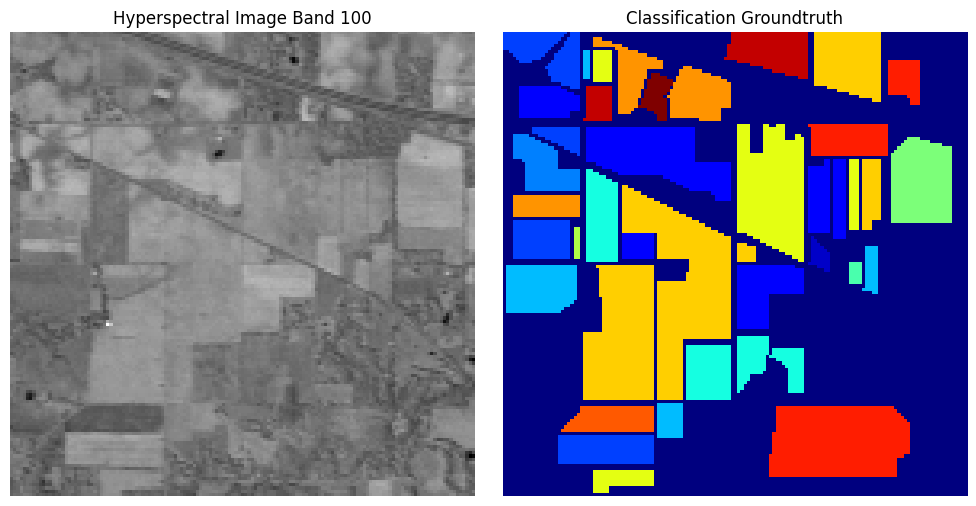

In [ ]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np

# Load the hyperspectral data
hsi = loadmat('indian_pines/Indian_pines.mat')['indian_pines'].astype(float)
GT = loadmat('indian_pines/Indian_pines_gt.mat')['indian_pines_gt'].astype(float)

# Remove water absorption bands
water_absorption_bands = np.append(np.arange(104,109),(np.arange(150, 163)))
hsi = np.delete(hsi,water_absorption_bands-1,axis=2)

fig, axs = plt.subplots(1, 2, figsize=(10, 5), tight_layout=True)
axs[0].imshow(hsi[:, :, 100], cmap='gray')
axs[0].axis('off')
axs[0].set_title('Hyperspectral Image Band 100')

# Plot the spectrum
axs[1].imshow(GT, cmap='jet')
axs[1].axis('off')
axs[1].set_title('Classification Groundtruth')

plt.show()

In [ ]:
# Generate Samples for Training and Testing
(x,y,L)=hsi.shape
N=x*y

hsi=np.reshape(hsi,(N,L))
GT=np.reshape(GT,(N,))

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(hsi[GT!=0,:], GT[GT!=0], train_size = 0.1, random_state=0)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, recall_score, precision_score
import pandas as pd

# Evaluation of classifiers
def classification_evaluation(y_test, y_predict, n_class=16):
  recall=recall_score(y_test, y_predict, average=None) * 100
  precision=precision_score(y_test, y_predict, average=None) * 100
  OA=accuracy_score(y_test, y_predict) * 100
  AA=recall_score(y_test, y_predict, average="macro") * 100

  # Create a dataframe to display the metrics
  metrics_df = pd.DataFrame({
      'Recall (%)': recall,
      'Precision (%)': precision,
      '# of Test Samples': [np.sum(y_test==i+1) for i in range(n_class)],
      '# of Train Samples': [np.sum(y_train==i+1) for i in range(n_class)],
  })

  metrics_df.reset_index()
  metrics_df.index = metrics_df.index + 1

  pd.options.display.precision = 2

  print(metrics_df.to_string())

  metrics_image_df = pd.DataFrame({
      'values': [OA, AA],
      }, index=(['OA(%)','AA(%)']))

  print(metrics_image_df.to_string(header=False))
  return {"recall":recall, "precision":precision, "OA":OA, "AA":AA}


## Support Vector Machine (SVM)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


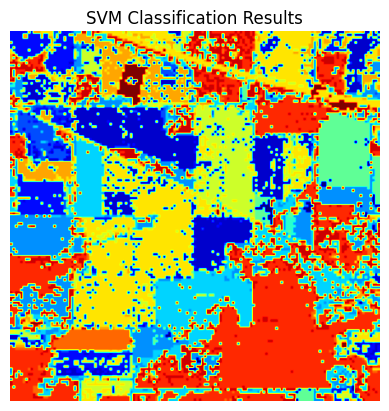

In [ ]:
# Support Vector Machine Classification
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svc', SVC())
    ])

param_svm = [
    {'svc__C': 10.0**np.arange(-2,5,1), 'svc__gamma': 10.0**np.arange(-3,3,1), 'svc__kernel': ['rbf']},
    ]

clf = GridSearchCV(pipe_svm, param_svm)
clf.fit(X_train, y_train)

y_predict_svm = clf.best_estimator_.predict(X_test)

results_svm = clf.best_estimator_.predict(hsi)
results_svm = np.reshape(results_svm,(x,y))

plt.figure()
plt.imshow(results_svm, cmap='jet')
plt.axis('off')
plt.title('SVM Classification Results')
plt.show()

In [ ]:
# Classification Performance Evaluation
performance_svm = classification_evaluation(y_test, y_predict_svm, n_class=16)

    Recall (%)  Precision (%)  # of Test Samples  # of Train Samples
1        25.58          50.00                 43                   3
2        84.51          72.33               1259                 169
3        69.84          73.54                756                  74
4        65.55          66.18                209                  28
5        91.80          87.31                427                  56
6        96.29          88.12                647                  83
7        73.08          90.48                 26                   2
8        98.36          90.73                428                  50
9        36.84          87.50                 19                   1
10       70.29          74.29                892                  80
11       77.79          80.48               2220                 235
12       69.26          74.35                540                  53
13       98.92          88.41                185                  20
14       93.57          92.68     

## Random Forest (RF)

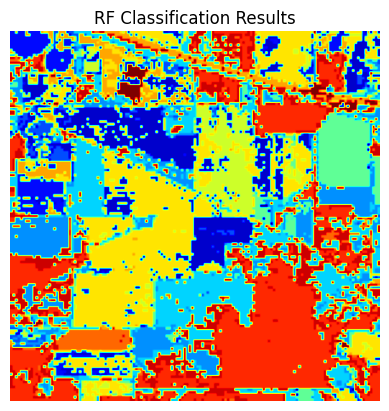

    Recall (%)  Precision (%)  # of Test Samples  # of Train Samples
1         4.65         100.00                 43                   3
2        73.95          66.88               1259                 169
3        53.17          80.24                756                  74
4        44.50          44.71                209                  28
5        87.82          84.84                427                  56
6        95.05          81.67                647                  83
7         0.00           0.00                 26                   2
8        99.77          79.52                428                  50
9         0.00           0.00                 19                   1
10       56.73          75.52                892                  80
11       84.05          69.21               2220                 235
12       43.52          62.33                540                  53
13       97.30          81.82                185                  20
14       93.93          92.78     

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Random Forest Classification
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('scaler', MinMaxScaler()),
    ('rf', RandomForestClassifier(n_estimators=500, oob_score=True))
    ])

pipe_rf.fit(X_train, y_train)
y_predict_rf = pipe_rf.predict(X_test)

results_rf = pipe_rf.predict(hsi)
results_rf = np.reshape(results_rf,(x,y))

plt.figure()
plt.imshow(results_rf, cmap='jet')
plt.axis('off')
plt.title('RF Classification Results')
plt.show()

performance_rf = classification_evaluation(y_test, y_predict_rf, n_class=16)


## Neural Network Classification

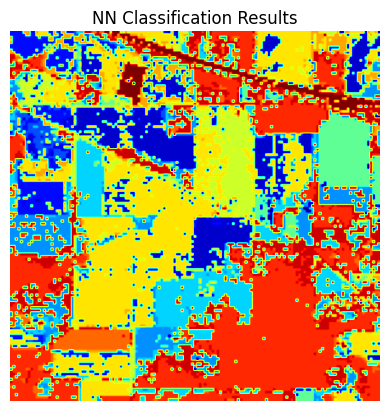

    Recall (%)  Precision (%)  # of Test Samples  # of Train Samples
1         9.30          50.00                 43                   3
2        69.98          70.42               1259                 169
3        57.94          70.53                756                  74
4        46.89          77.78                209                  28
5        76.58          80.94                427                  56
6        91.34          86.15                647                  83
7         0.00           0.00                 26                   2
8        99.77          86.61                428                  50
9         0.00           0.00                 19                   1
10       50.90          71.72                892                  80
11       85.68          63.40               2220                 235
12       26.11          52.42                540                  53
13       98.38          87.08                185                  20
14       96.74          87.08     

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Neural Network
from sklearn.neural_network import MLPClassifier

pipe_nn = Pipeline([
    ('scaler', MinMaxScaler()),
    ('nn', MLPClassifier(solver='adam', hidden_layer_sizes=(20), random_state=1, batch_size=20, max_iter=1000, learning_rate_init=0.001))
    ])

pipe_nn.fit(X_train, y_train)
y_predict_nn = pipe_nn.predict(X_test)

results_nn = pipe_nn.predict(hsi)
results_nn = np.reshape(results_nn,(x,y))

plt.figure()
plt.imshow(results_nn, cmap='jet')
plt.axis('off')
plt.title('NN Classification Results')
plt.show()

performance_svm = classification_evaluation(y_test, y_predict_nn, n_class=16)
